<a href="https://colab.research.google.com/github/bhudevbhanpuriya/fetal-ecg-arrhythmia/blob/main/full_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wfdb
!wget -r -N -c -np https://physionet.org/files/nifeadb/1.0.0/ -P ./nifeadb/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 77.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
--2026-04-16 17:19:29--  https://physionet.org/files/nifeadb/

In [1]:
# ============================================================
# STEP 2 — Install libraries
# ============================================================
!pip install wfdb scipy numpy matplotlib scikit-learn tensorflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 105.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have 

In [5]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample_poly
import os

# ── Config ──────────────────────────────────────────────────
# Since files are uploaded to the root /content/ folder
DATA_DIR     = '/content/'
TARGET_FS    = 500          # paper resamples everything to 500 Hz
ARR_IDS      = [f'ARR_{i:02d}' for i in range(1, 13)]   # 12 arrhythmia
NR_IDS       = [f'NR_{i:02d}'  for i in range(1, 15)]   # 14 normal
ALL_IDS      = ARR_IDS + NR_IDS

# ── Helper: load one subject ─────────────────────────────────
def load_subject(record_id, data_dir=DATA_DIR):
    """
    Returns
    -------
    aecg      : np.ndarray, shape (n_samples, n_abdominal_channels)
    fs        : int, original sampling frequency
    label     : int, 1 = arrhythmia  0 = normal
    """
    # Construct local path
    record_path = os.path.join(data_dir, record_id)

    # Read local WFDB record
    record = wfdb.rdrecord(record_path)

    sig_names = [s.lower() for s in record.sig_name]
    fs        = record.fs
    signals   = record.p_signal

    # Keep only abdominal channels
    abdom_idx = [i for i, n in enumerate(sig_names) if 'abdom' in n]
    if not abdom_idx:
        abdom_idx = list(range(signals.shape[1] - 1))

    aecg = signals[:, abdom_idx]

    # Resample to 500 Hz
    if fs != TARGET_FS:
        up, down = TARGET_FS, fs
        from math import gcd
        g    = gcd(up, down)
        aecg = resample_poly(aecg, up // g, down // g, axis=0)

    label = 1 if record_id.startswith('ARR') else 0
    return aecg, TARGET_FS, label

# ── Load all subjects ────────────────────────────────────────
dataset = {}

print("Starting data loading...")
for rid in ALL_IDS:
    if not os.path.exists(os.path.join(DATA_DIR, rid + '.hea')):
        continue

    try:
        aecg, fs, label = load_subject(rid)
        dataset[rid] = {'aecg': aecg, 'fs': fs, 'label': label}
        tag = 'ARR' if label else 'NR '
        print(f'  [{tag}] {rid:8s}  shape={aecg.shape}  fs={fs} Hz')
    except Exception as e:
        print(f'  [WARN] {rid} — {e}')

print(f'\nSuccessfully loaded {len(dataset)} / {len(ALL_IDS)} subjects')

Starting data loading...
  [ARR] ARR_01    shape=(300026, 5)  fs=500 Hz
  [ARR] ARR_02    shape=(302012, 5)  fs=500 Hz
  [ARR] ARR_03    shape=(378949, 5)  fs=500 Hz
  [ARR] ARR_04    shape=(302604, 5)  fs=500 Hz
  [ARR] ARR_05    shape=(240845, 5)  fs=500 Hz
  [ARR] ARR_06    shape=(961521, 5)  fs=500 Hz
  [ARR] ARR_07    shape=(309423, 5)  fs=500 Hz
  [ARR] ARR_08    shape=(660803, 5)  fs=500 Hz
  [ARR] ARR_09    shape=(332900, 5)  fs=500 Hz
  [ARR] ARR_10    shape=(303559, 4)  fs=500 Hz
  [ARR] ARR_11    shape=(302589, 5)  fs=500 Hz
  [ARR] ARR_12    shape=(302576, 5)  fs=500 Hz
  [NR ] NR_01     shape=(302952, 5)  fs=500 Hz
  [NR ] NR_02     shape=(302513, 5)  fs=500 Hz
  [NR ] NR_03     shape=(303897, 5)  fs=500 Hz
  [NR ] NR_04     shape=(310004, 5)  fs=500 Hz
  [NR ] NR_05     shape=(302576, 5)  fs=500 Hz
  [NR ] NR_06     shape=(313865, 5)  fs=500 Hz
  [NR ] NR_07     shape=(305018, 5)  fs=500 Hz
  [NR ] NR_08     shape=(300086, 5)  fs=500 Hz
  [NR ] NR_09     shape=(377324, 5)

Starting data loading...
  [ARR] ARR_01    shape=(300026, 5)  fs=500 Hz
  [ARR] ARR_02    shape=(302012, 5)  fs=500 Hz
  [ARR] ARR_03    shape=(378949, 5)  fs=500 Hz
  [ARR] ARR_04    shape=(302604, 5)  fs=500 Hz
  [ARR] ARR_05    shape=(240845, 5)  fs=500 Hz
  [ARR] ARR_06    shape=(961521, 5)  fs=500 Hz
  [ARR] ARR_07    shape=(309423, 5)  fs=500 Hz
  [ARR] ARR_08    shape=(660803, 5)  fs=500 Hz
  [ARR] ARR_09    shape=(332900, 5)  fs=500 Hz
  [ARR] ARR_10    shape=(303559, 4)  fs=500 Hz
  [ARR] ARR_11    shape=(302589, 5)  fs=500 Hz
  [ARR] ARR_12    shape=(302576, 5)  fs=500 Hz
  [NR ] NR_01     shape=(302952, 5)  fs=500 Hz
  [NR ] NR_02     shape=(302513, 5)  fs=500 Hz
  [NR ] NR_03     shape=(303897, 5)  fs=500 Hz
  [NR ] NR_04     shape=(310004, 5)  fs=500 Hz
  [NR ] NR_05     shape=(302576, 5)  fs=500 Hz
  [NR ] NR_06     shape=(313865, 5)  fs=500 Hz
  [NR ] NR_07     shape=(305018, 5)  fs=500 Hz
  [NR ] NR_08     shape=(300086, 5)  fs=500 Hz
  [NR ] NR_09     shape=(377324, 5)

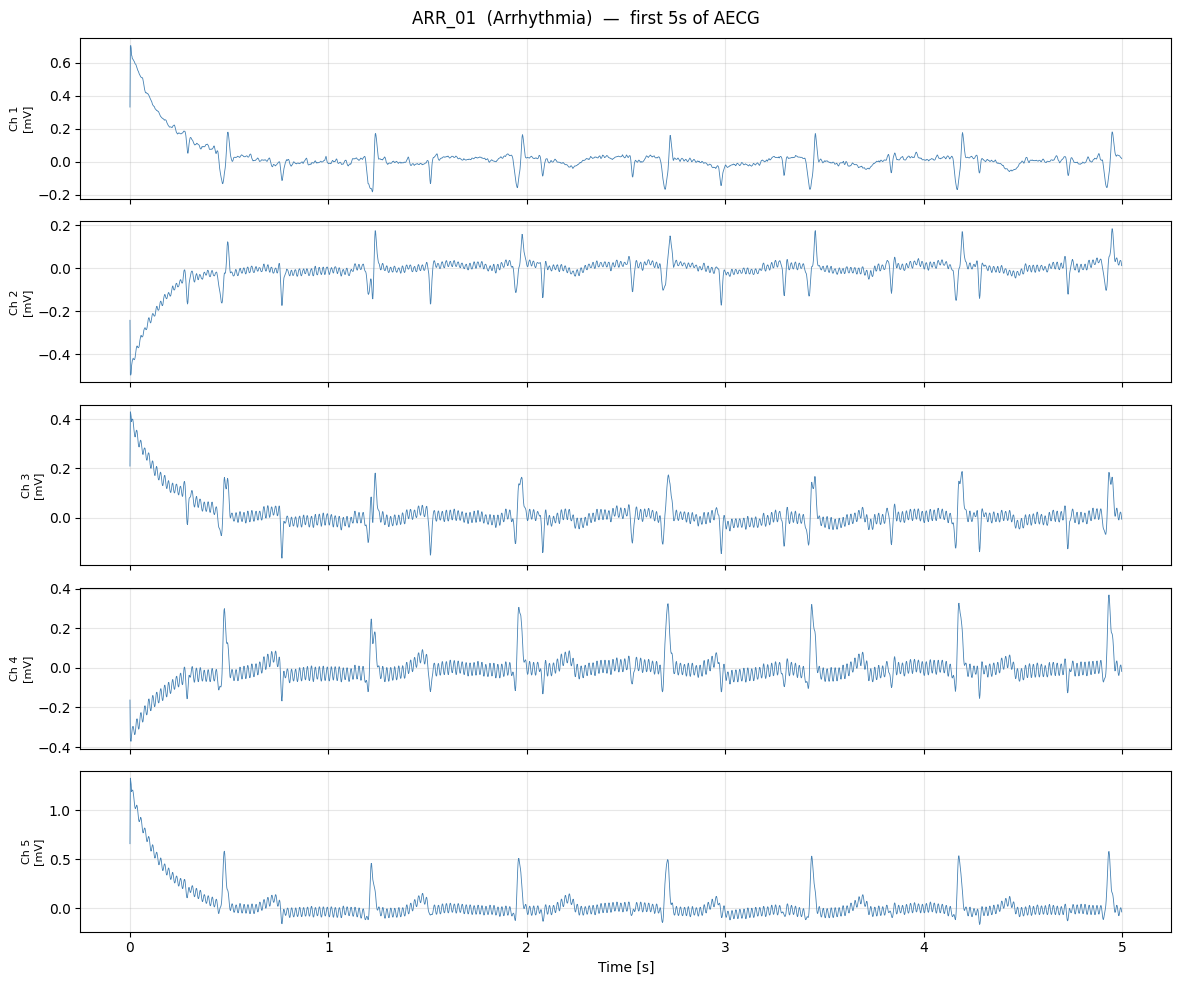

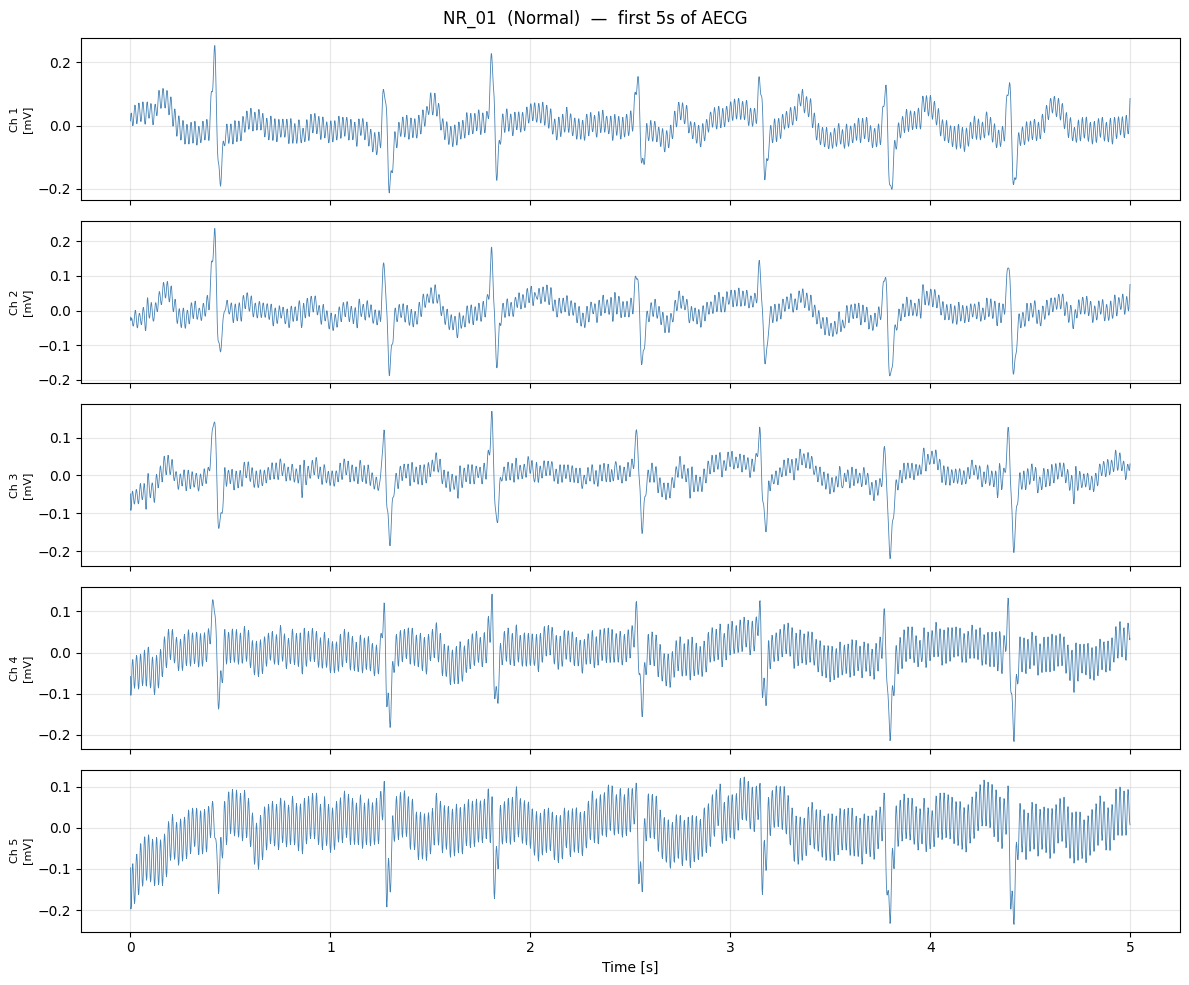

In [8]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample_poly
import os

# ── Config ──────────────────────────────────────────────────
# Updated to root /content/ where files were uploaded
DATA_DIR     = '/content/'
TARGET_FS    = 500          # paper resamples everything to 500 Hz
ARR_IDS      = [f'ARR_{i:02d}' for i in range(1, 13)]   # 12 arrhythmia
NR_IDS       = [f'NR_{i:02d}'  for i in range(1, 15)]   # 14 normal
ALL_IDS      = ARR_IDS + NR_IDS

# ── Helper: load one subject ─────────────────────────────────
def load_subject(record_id, data_dir=DATA_DIR):
    """
    Returns
    -------
    aecg      : np.ndarray, shape (n_samples, n_abdominal_channels)
    fs        : int, original sampling frequency
    label     : int, 1 = arrhythmia  0 = normal
    """
    # Construct local path
    record_path = os.path.join(data_dir, record_id)

    # Read local WFDB record
    record = wfdb.rdrecord(record_path)

    sig_names = [s.lower() for s in record.sig_name]
    fs        = record.fs
    signals   = record.p_signal

    # Keep only abdominal channels
    abdom_idx = [i for i, n in enumerate(sig_names) if 'abdom' in n]
    if not abdom_idx:
        # Fallback: drop last channel
        abdom_idx = list(range(signals.shape[1] - 1))

    aecg = signals[:, abdom_idx]

    # Resample to 500 Hz
    if fs != TARGET_FS:
        up, down = TARGET_FS, fs
        from math import gcd
        g    = gcd(up, down)
        aecg = resample_poly(aecg, up // g, down // g, axis=0)

    label = 1 if record_id.startswith('ARR') else 0
    return aecg, TARGET_FS, label


# ── Load all subjects ────────────────────────────────────────
dataset = {}

print("Starting data loading...")
for rid in ALL_IDS:
    # Only try to load if the header file exists
    if not os.path.exists(os.path.join(DATA_DIR, rid + '.hea')):
        continue

    try:
        aecg, fs, label = load_subject(rid)
        dataset[rid] = {'aecg': aecg, 'fs': fs, 'label': label}
        tag = 'ARR' if label else 'NR '
        print(f'  [{tag}] {rid:8s}  shape={aecg.shape}  fs={fs} Hz')
    except Exception as e:
        print(f'  [WARN] {rid} — {e}')

print(f'\nSuccessfully loaded {len(dataset)} / {len(ALL_IDS)} subjects')

# ── Quick sanity-check plot ──────────────────────────────────
def plot_subject(record_id, duration_s=5):
    if record_id not in dataset: return
    d      = dataset[record_id]
    aecg   = d['aecg']
    fs     = d['fs']
    label  = d['label']
    n_show = duration_s * fs
    t      = np.arange(n_show) / fs

    n_ch = aecg.shape[1]
    fig, axes = plt.subplots(n_ch, 1, figsize=(12, 2 * n_ch), sharex=True)
    tag = 'Arrhythmia' if label else 'Normal'

    fig.suptitle(f'{record_id}  ({tag})  —  first {duration_s}s of AECG', fontsize=12)

    if n_ch == 1: axes = [axes]
    for i, ax in enumerate(axes):
        ax.plot(t, aecg[:n_show, i], lw=0.6, color='steelblue')
        ax.set_ylabel(f'Ch {i+1}\n[mV]', fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()

# Plot one arrhythmia and one normal subject if available
if 'ARR_01' in dataset: plot_subject('ARR_01')
if 'NR_01' in dataset: plot_subject('NR_01')

In [9]:
# ── Dataset summary ──────────────────────────────────────────
arr_count = sum(1 for v in dataset.values() if v['label'] == 1)
nr_count  = sum(1 for v in dataset.values() if v['label'] == 0)

print('=== Dataset summary ===')
print(f'  Arrhythmia subjects : {arr_count}')
print(f'  Normal subjects     : {nr_count}')
print(f'  Total               : {arr_count + nr_count}')
print(f'  Target sample rate  : {TARGET_FS} Hz')

print('\n=== Recording Durations ===')
# Show recording durations
for rid, d in dataset.items():
    dur = d['aecg'].shape[0] / d['fs']
    print(f'  {rid:8s}  {dur:.1f}s  channels={d["aecg"].shape[1]}')

=== Dataset summary ===
  Arrhythmia subjects : 12
  Normal subjects     : 14
  Total               : 26
  Target sample rate  : 500 Hz

=== Recording Durations ===
  ARR_01    600.1s  channels=5
  ARR_02    604.0s  channels=5
  ARR_03    757.9s  channels=5
  ARR_04    605.2s  channels=5
  ARR_05    481.7s  channels=5
  ARR_06    1923.0s  channels=5
  ARR_07    618.8s  channels=5
  ARR_08    1321.6s  channels=5
  ARR_09    665.8s  channels=5
  ARR_10    607.1s  channels=4
  ARR_11    605.2s  channels=5
  ARR_12    605.2s  channels=5
  NR_01     605.9s  channels=5
  NR_02     605.0s  channels=5
  NR_03     607.8s  channels=5
  NR_04     620.0s  channels=5
  NR_05     605.2s  channels=5
  NR_06     627.7s  channels=5
  NR_07     610.0s  channels=5
  NR_08     600.2s  channels=5
  NR_09     754.6s  channels=5
  NR_10     600.0s  channels=5
  NR_11     602.5s  channels=5
  NR_12     440.9s  channels=5
  NR_13     604.0s  channels=5
  NR_14     610.0s  channels=5


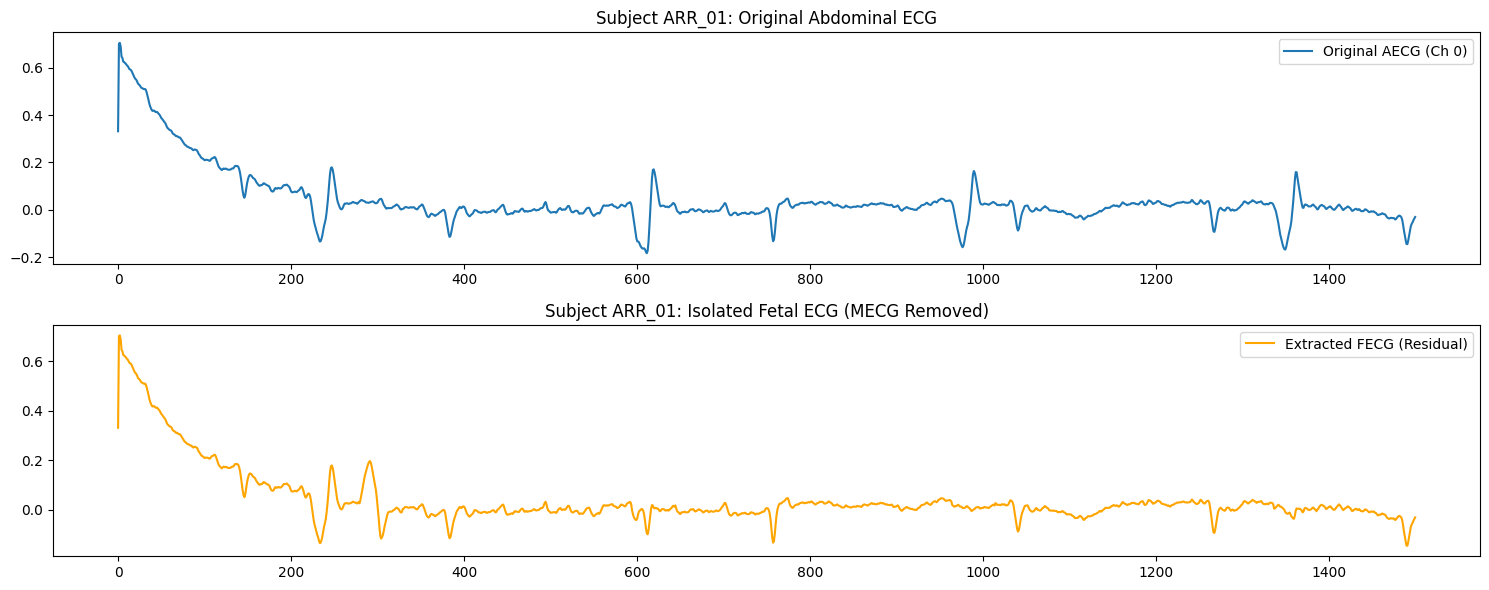

Extracting FECG for all subjects...
Extraction complete.


In [11]:
# ============================================================
# STEP 3 — FECG Extraction (Maternal Template Subtraction)
# ============================================================
from scipy.signal import find_peaks

def extract_fecg(aecg_sig, fs=500):
    """
    Simple template subtraction to isolate FECG.
    """
    fecg_channels = []
    for i in range(aecg_sig.shape[1]):
        sig = aecg_sig[:, i]
        # Detect maternal R-peaks (maternal is usually much stronger)
        peaks, _ = find_peaks(sig, distance=fs*0.6, height=np.mean(sig) + np.std(sig))

        # Create a simple template (average of windows around peaks)
        win = int(0.05 * fs) # 50ms window
        template = np.zeros(2 * win)
        count = 0
        for p in peaks:
            if p > win and p < len(sig) - win:
                template += sig[p-win : p+win]
                count += 1
        if count > 0: template /= count

        # Subtract template from each peak location
        clean_sig = sig.copy()
        for p in peaks:
            if p > win and p < len(sig) - win:
                clean_sig[p-win : p+win] -= template
        fecg_channels.append(clean_sig)

    return np.array(fecg_channels).T

# Process a sample subject (e.g., ARR_01)
sample_id = 'ARR_01'
aecg_sample = dataset[sample_id]['aecg']
fecg_sample = extract_fecg(aecg_sample)

# Visualization
plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
plt.plot(aecg_sample[:1500, 0], label='Original AECG (Ch 0)')
plt.title(f'Subject {sample_id}: Original Abdominal ECG')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(fecg_sample[:1500, 0], label='Extracted FECG (Residual)', color='orange')
plt.title(f'Subject {sample_id}: Isolated Fetal ECG (MECG Removed)')
plt.legend()
plt.tight_layout()
plt.show()

# Store FECG back into dataset
print("Extracting FECG for all subjects...")
for rid in dataset:
    dataset[rid]['fecg'] = extract_fecg(dataset[rid]['aecg'])
print("Extraction complete.")

In [13]:
# ============================================================
# STEP 4 — Fetal R-peak Detection & Segmentation
# ============================================================

def segment_data(dataset, window_size=1500, step=500):
    X, y = [], []

    print("Segmenting data into windows...")
    for rid, data in dataset.items():
        fecg = data['fecg'][:, 0] # Use first channel for peak detection
        label = data['label']

        # Detect Fetal R-peaks (Fetal peaks are smaller and faster than maternal)
        # Note: In a production setting, a more robust detector like Pan-Tompkins would be used.
        peaks, _ = find_peaks(fecg, distance=TARGET_FS*0.3, height=np.std(fecg)*0.5)

        # Slide window across the signal
        for start in range(0, len(fecg) - window_size, step):
            end = start + window_size
            segment = fecg[start:end]

            # Normalize segment
            segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

            X.append(segment.reshape(window_size, 1))
            y.append(label)

    return np.array(X), np.array(y)

# Create segments for the CNN
X_data, y_data = segment_data(dataset)

print(f"Created {len(X_data)} segments.")
print(f"Shape of X: {X_data.shape}")
print(f"Class distribution: {np.bincount(y_data)}")

Segmenting data into windows...
Created 17827 segments.
Shape of X: (17827, 1500, 1)
Class distribution: [8460 9367]


In [15]:
# ============================================================
# STEP 5 — Build the CNN (Paper Architecture)
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_shape=(1500, 1)):
    model = models.Sequential([
        # First Conv Block
        layers.Conv1D(32, 128, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(2),

        # Second Conv Block
        layers.Conv1D(32, 128, activation='relu'),
        layers.MaxPooling1D(2),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid') # Binary classification: Normal vs Arrhythmia
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 1373, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 686, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 559, 32)        │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 279, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,571,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,707,393 (17.96 MB)

 Trainable params: 4,707,393 (17.96 MB)

 Non-trainable params: 0 (0.00 B)

Training on 14261 samples, validating on 3566 samples
Epoch 1/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8424 - loss: 0.4422 - val_accuracy: 0.8985 - val_loss: 0.2749
Epoch 2/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9116 - loss: 0.2560 - val_accuracy: 0.9240 - val_loss: 0.2274
Epoch 3/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9170 - loss: 0.2401 - val_accuracy: 0.9262 - val_loss: 0.2153
Epoch 4/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9323 - loss: 0.2010 - val_accuracy: 0.9408 - val_loss: 0.1888
Epoch 5/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9440 - loss: 0.1793 - val_accuracy: 0.9411 - val_loss: 0.1844
Epoch 6/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9522 - loss: 0.1607 - val_accuracy: 0.9464 - val_loss: 0.1726
Epoch 7/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9490 - loss: 0.1666 - val_accuracy: 0.9543 - val_loss: 0.1594
Epoch 8/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 3

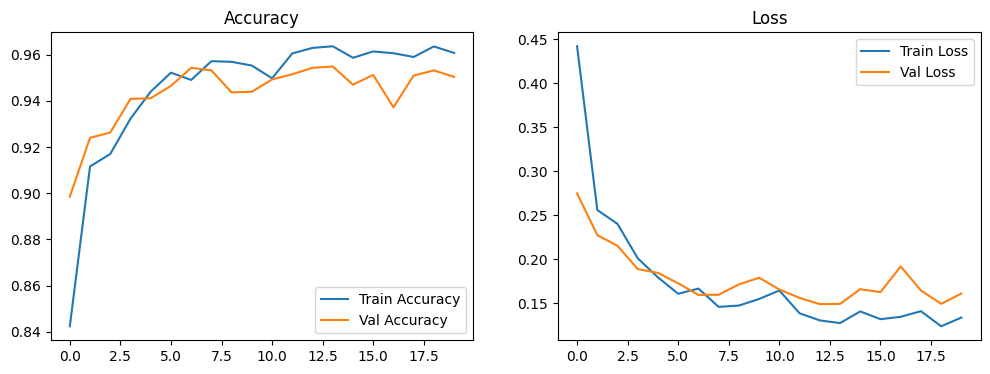

In [17]:
# ============================================================
# STEP 6 — Training
# ============================================================
from sklearn.model_selection import train_test_split

# Split data into training and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

print(f"Training on {len(X_train)} samples, validating on {len(X_val)} samples")

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import accuracy_score, recall_score, precision_score
import numpy as np

# ============================================================
# STEP 7 — Full Leave-One-Subject-Out (LOSO) Cross-Validation
# ============================================================

def get_subject_data(subject_id, dataset, window_size=1500, step=500):
    X, y = [], []
    data = dataset[subject_id]
    fecg = data['fecg'][:, 0]
    label = data['label']
    for start in range(0, len(fecg) - window_size, step):
        segment = fecg[start:start+window_size]
        segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)
        X.append(segment.reshape(window_size, 1))
        y.append(label)
    return np.array(X), np.array(y)

all_subjects = list(dataset.keys())
loso_accuracies = []

print(f"Starting Full LOSO Cross-Validation on {len(all_subjects)} subjects...")

for test_subject in all_subjects:
    # Prepare training data (all except current test_subject)
    X_train_loso, y_train_loso = [], []
    for sub in all_subjects:
        if sub == test_subject: continue
        xs, ys = get_subject_data(sub, dataset)
        X_train_loso.append(xs)
        y_train_loso.extend([ys[0]] * len(xs))

    X_train_loso = np.concatenate(X_train_loso)
    y_train_loso = np.array(y_train_loso)

    # Prepare test data
    X_test_loso, y_test_loso = get_subject_data(test_subject, dataset)

    # Build fresh model and train (fewer epochs for speed in LOSO loop)
    loso_model = build_model()
    loso_model.fit(X_train_loso, y_train_loso, epochs=5, batch_size=128, verbose=0)

    # Evaluate subject-level performance
    y_pred_probs = loso_model.predict(X_test_loso, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int)

    # The paper often classifies the entire subject based on the majority window vote
    # or checks if any window is positive. Here we'll report window-level accuracy per subject.
    acc = accuracy_score(y_test_loso, y_pred)
    loso_accuracies.append(acc)
    print(f"  Subject {test_subject:8s} -> Accuracy: {acc:.4f}")

print("\n=== Final LOSO Results ===")
print(f"Average LOSO Accuracy: {np.mean(loso_accuracies):.4f}")
print(f"Standard Deviation:   {np.std(loso_accuracies):.4f}")

Starting Full LOSO Cross-Validation on 26 subjects...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Subject ARR_01   -> Accuracy: 0.9983


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Subject ARR_02   -> Accuracy: 0.0000


...

  Subject NR_12    -> Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Subject NR_13    -> Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Subject NR_14    -> Accuracy: 0.9918

=== Final LOSO Results ===
Average LOSO Accuracy: 0.8235
Standard Deviation:   0.3430


112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.92      0.98      0.95      1692
  Arrhythmia       0.98      0.92      0.95      1874

    accuracy                           0.95      3566
   macro avg       0.95      0.95      0.95      3566
weighted avg       0.95      0.95      0.95      3566



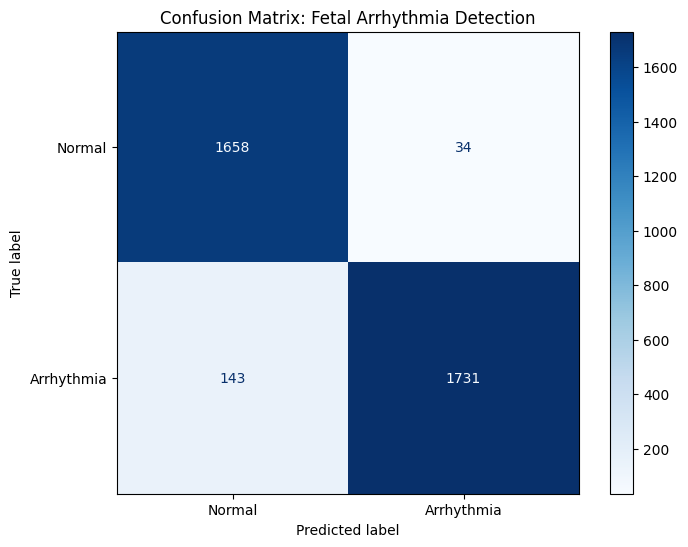


Final Performance Metrics:
  Accuracy  : 0.9504
  Precision : 0.9807
  Recall    : 0.9237


In [21]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# ============================================================
# STEP 8 — Final Evaluation & Metrics
# ============================================================

# Generate predictions for the validation set
y_pred_probs = model.predict(X_val)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# 1. Classification Report
print("=== Classification Report ===")
target_names = ['Normal', 'Arrhythmia']
print(classification_report(y_val, y_pred_classes, target_names=target_names))

# 2. Confusion Matrix
cm = confusion_matrix(y_val, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Fetal Arrhythmia Detection')
plt.show()

# 3. Final Summary Metrics
final_acc = accuracy_score(y_val, y_pred_classes)
final_prec = precision_score(y_val, y_pred_classes)
final_rec = recall_score(y_val, y_pred_classes)

print(f"\nFinal Performance Metrics:")
print(f"  Accuracy  : {final_acc:.4f}")
print(f"  Precision : {final_prec:.4f}")
print(f"  Recall    : {final_rec:.4f}")